In [2]:
import pandas as pd
import sqlite3

In [3]:
connection = sqlite3.connect('../data/checking-logs.sqlite')
pd.read_sql('SELECT * FROM checker LIMIT 2', connection)

,index,status,success,timestamp,numTrials,labname,uid
0,0,checking,0,2020-04-16 21:12:50.740474,5,None,admin_1
1,1,ready,0,2020-04-16 21:12:54.708365,5,code_rvw,admin_1


In [4]:
query = '''
SELECT
    timestamp AS datetime,
    COUNT(*) AS commits
FROM
    checker
WHERE uid LIKE 'user%'
GROUP BY datetime
'''
df = pd.read_sql(query, connection)

In [5]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour

In [6]:
labels = ['night', 'morning', 'afternoon', 'evening']
bins = [0, 4, 10, 17, 24]
df['daytime'] = pd.cut(df['hour'], bins=bins, labels=labels, right=False)
df['date'] = df['datetime'].dt.date
df

,datetime,commits,hour,daytime,date
0,2020-04-17 05:19:02.744528,1,5,morning,2020-04-17
1,2020-04-17 05:22:35.249331,1,5,morning,2020-04-17
2,2020-04-17 05:22:45.549397,1,5,morning,2020-04-17
3,2020-04-17 05:34:14.691200,1,5,morning,2020-04-17
4,2020-04-17 05:34:24.422370,1,5,morning,2020-04-17
...,...,...,...,...,...
3202,2020-05-21 20:19:06.872761,1,20,evening,2020-05-21
3203,2020-05-21 20:22:41.785725,1,20,evening,2020-05-21
3204,2020-05-21 20:22:41.877806,1,20,evening,2020-05-21
3205,2020-05-21 20:37:00.129678,1,20,evening,2020-05-21


In [7]:
commits = df.groupby(['date', 'daytime'], observed = False).size().unstack(fill_value=0)
commits

daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,33,35
2020-04-19,2,4,16,11
2020-04-20,0,0,12,13
2020-04-21,0,0,0,25
2020-04-22,0,0,4,24
2020-04-23,2,6,15,20
2020-04-24,0,0,4,12
2020-04-25,1,21,33,49


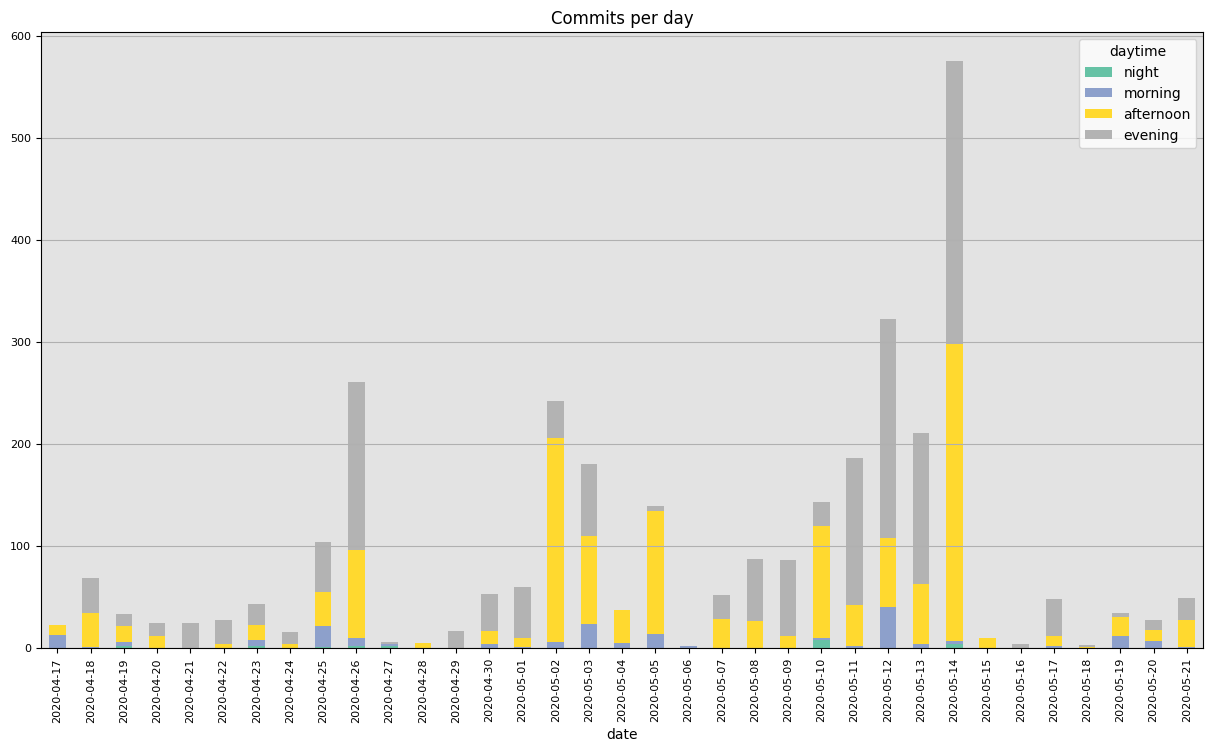

In [8]:
ax = commits.plot(kind='bar', stacked=True, figsize=(15,8), fontsize=8, colormap='Set2', legend=True)
ax.set_title('Commits per day')
ax.set_xlabel('date')
ax.tick_params(axis='x', rotation=90)
ax.grid(axis='y')
ax.set_facecolor('#E3E3E3')

Когда наши пользователи обычно заходят в лаборатории: ночью, утром, днём или вечером? Ответ: чаще всего в два из этих периодов.

In [9]:
df['daytime'].value_counts()

daytime
evening      1611
afternoon    1391
morning       184
night          21
Name: count, dtype: int64


# **Вечером**

В какой день:
    - наибольшее количество коммитов?
    - и в то же время, больше ли коммитов совершается вечером, чем днём?

In [10]:
commits[commits['evening'] > commits['afternoon']].sum(axis=1).idxmax()

datetime.date(2020, 5, 12)

# **2020.05.12**

In [12]:
connection.close()